Prompt: I'll help you implement the U-Net architecture for semantic segmentation, as well as a variant without skip connections as requested in your assignment. Looking at the code you've provided, I can see you already have a complete implementation of the vanilla U-Net. I'll analyze it and then provide the code for the U-Net without skip connections.
Analysis of Your Current Code
Your code already implements the vanilla U-Net architecture as described in the paper. It includes:

A proper dataset class for loading segmentation data
The U-Net architecture with encoder-decoder structure and skip connections
Training/validation/testing functions with IoU metric calculation
Visualization functions for showing predictions

U-Net Without Skip Connections
For the second part of your assignment (3.2), you need to implement a U-Net without skip connections. This will demonstrate the importance of skip connections in preserving spatial information during the upsampling process.
Here's the implementation for the U-Net without skip connections:
U-Net Without Skip Connections ImplementationCode 
Key Differences in the No-Skip U-Net Implementation
The main differences between the vanilla U-Net and the U-Net without skip connections are:

UpNoSkip Class: Instead of concatenating features from the encoder path, this class simply upsamples the features and applies convolutions.
UNetNoSkip Forward Method: The decoder path doesn't use the encoder features, which means there are no skip connections.
Output Files: Changed file names to differentiate from the vanilla U-Net implementation (e.g., 'unet_no_skip_predictions.png' instead of 'unet_vanilla_predictions.png').

Expected Results
When you run both implementations and compare them, you should observe:

The vanilla U-Net will likely achieve higher mIoU scores because skip connections help preserve fine spatial details.
The U-Net without skip connections will likely struggle with fine details in the segmentation masks, resulting in more blurry or less precise boundaries.
The loss curves and mIoU curves will show different convergence behaviors, with the skip connection version likely converging faster and reaching higher performance.

Using device: cuda:1
Training images: 2000
Test images: 500
Training samples: 1600
Validation samples: 400
Test samples: 500
UNetNoSkip(
  (inc): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): 

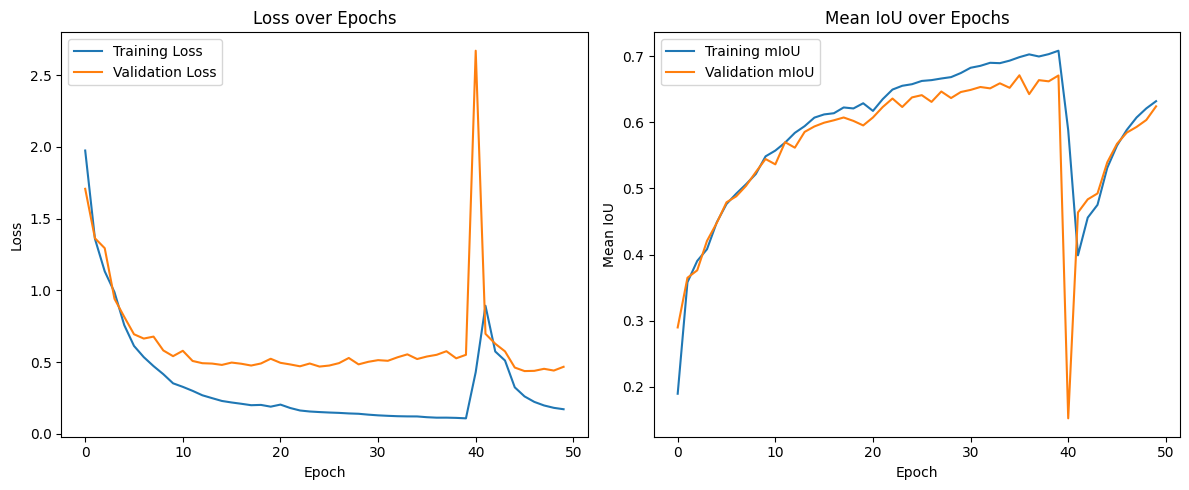

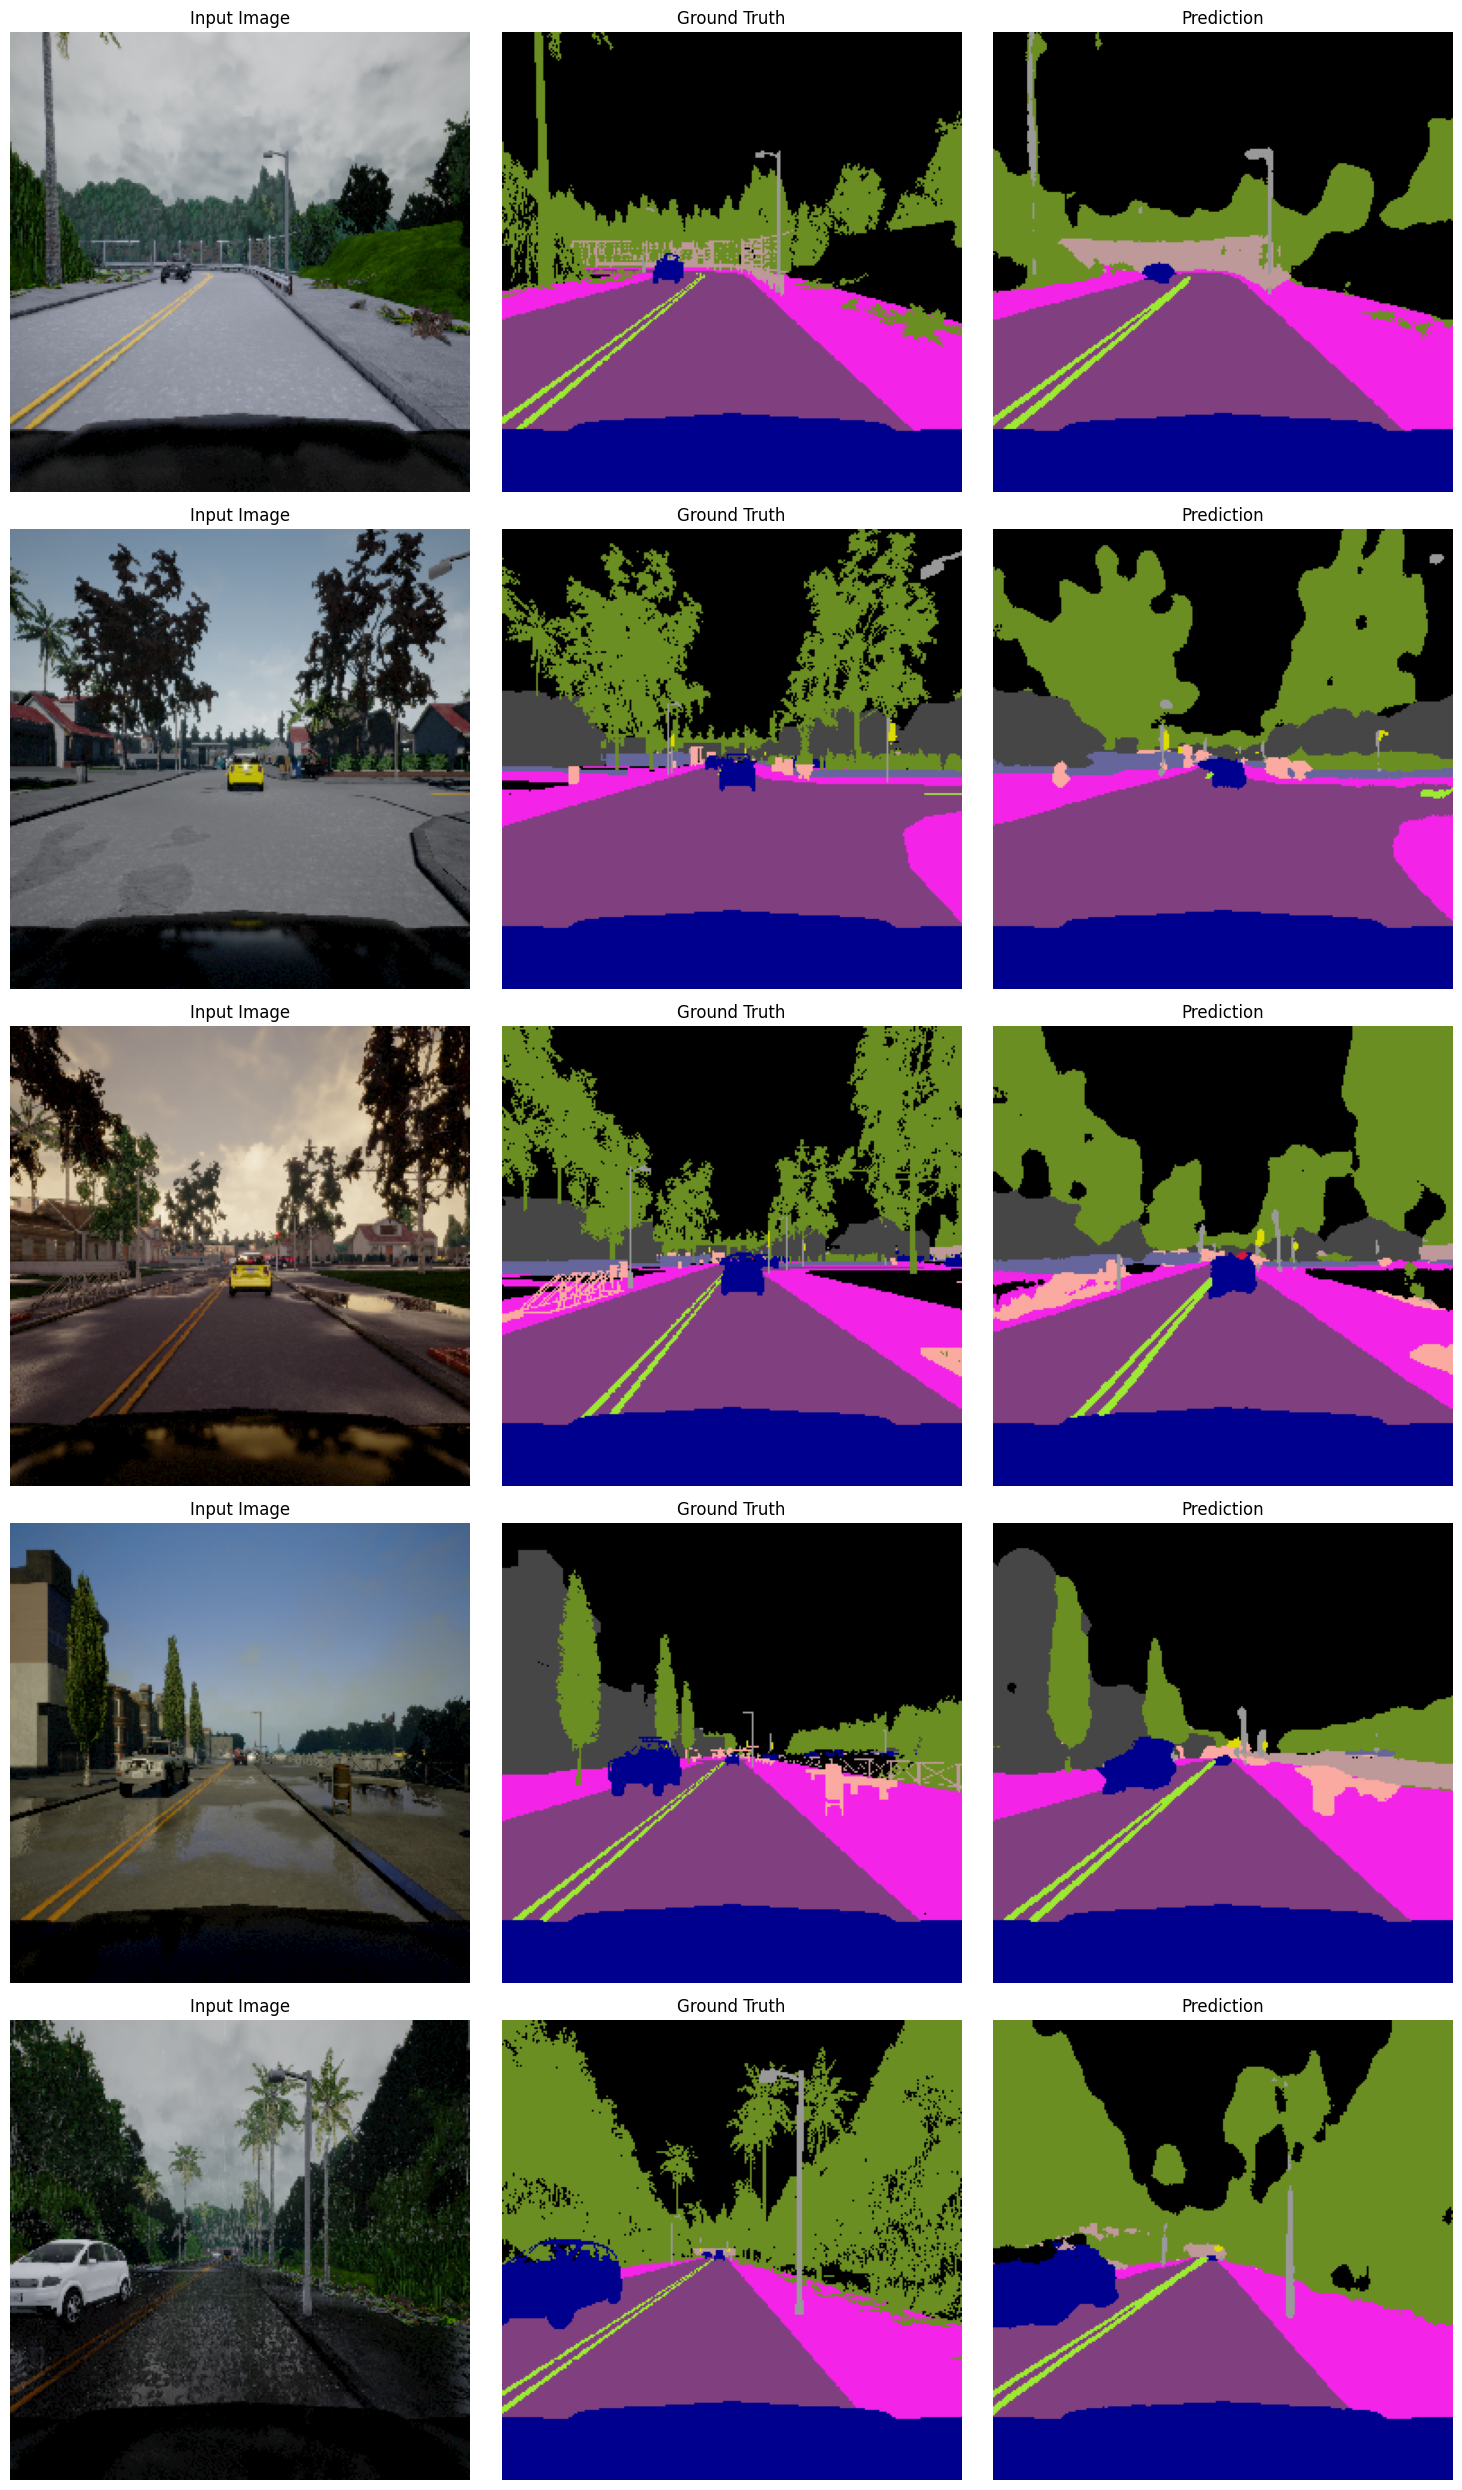

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define constants
IMG_WIDTH = 256
IMG_HEIGHT = 256
NUM_CLASSES = 13
BATCH_SIZE = 16
EPOCHS = 50
VAL_SPLIT = 0.2
LEARNING_RATE = 1e-4
DATASET_PATH = "Dataset/2/dataset_256"

# Define class names and colors for visualization
CLASS_NAMES = [
    "Unlabeled", "Building", "Fence", "Other", "Pedestrian", 
    "Pole", "Roadline", "Road", "Sidewalk", "Vegetation", 
    "Car", "Wall", "Traffic sign"
]

COLORS = np.array([
    [0, 0, 0],        # Unlabeled - black
    [70, 70, 70],     # Building - dark gray
    [190, 153, 153],  # Fence - light brown
    [250, 170, 160],  # Other - salmon
    [220, 20, 60],    # Pedestrian - crimson
    [153, 153, 153],  # Pole - gray
    [157, 234, 50],   # Roadline - bright green
    [128, 64, 128],   # Road - purple
    [244, 35, 232],   # Sidewalk - pink
    [107, 142, 35],   # Vegetation - olive green
    [0, 0, 142],      # Car - dark blue
    [102, 102, 156],  # Wall - slate blue
    [220, 220, 0]     # Traffic sign - yellow
]) / 255.0  # Normalize to [0, 1]

# Create a color map for visualization
COLORMAP = ListedColormap(COLORS)

###################
# DATASET CLASSES #
###################

class SegmentationDataset(Dataset):
    """Dataset class for semantic segmentation"""
    
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert('RGB')
        img = np.array(img) / 255.0  # Normalize to [0, 1]
        img = img.transpose(2, 0, 1)  # Convert to CxHxW format
        img = torch.from_numpy(img).float()
        
        # Load mask
        mask_path = self.mask_paths[idx]
        mask = Image.open(mask_path)
        mask = np.array(mask)
        if len(mask.shape) > 2:
            mask = mask[:, :, 0]  # Take only the first channel if multi-channel
        mask = torch.from_numpy(mask).long()
        
        # Apply transformations if specified
        if self.transform:
            img, mask = self.transform(img, mask)
            
        return img, mask

def load_data_paths(dataset_path):
    """Load paths to images and masks"""
    # Get paths to training images and masks
    train_img_paths = sorted(glob.glob(os.path.join(dataset_path, "train", "images", "*.png")))
    train_mask_paths = sorted(glob.glob(os.path.join(dataset_path, "train", "labels", "*.png")))
    
    # Get paths to test images and masks
    test_img_paths = sorted(glob.glob(os.path.join(dataset_path, "test", "images", "*.png")))
    test_mask_paths = sorted(glob.glob(os.path.join(dataset_path, "test", "labels", "*.png")))
    
    print(f"Training images: {len(train_img_paths)}")
    print(f"Test images: {len(test_img_paths)}")
    
    return train_img_paths, train_mask_paths, test_img_paths, test_mask_paths

def prepare_dataloaders(train_img_paths, train_mask_paths, test_img_paths, test_mask_paths):
    """Prepare dataloaders for training, validation, and testing"""
    # Create datasets
    train_dataset = SegmentationDataset(train_img_paths, train_mask_paths)
    test_dataset = SegmentationDataset(test_img_paths, test_mask_paths)
    
    # Split training data into training and validation
    val_size = int(len(train_dataset) * VAL_SPLIT)
    train_size = len(train_dataset) - val_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                             num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader, test_dataset

###################################
# U-NET WITHOUT SKIP CONNECTIONS #
###################################

class DoubleConv(nn.Module):
    """Double Convolution block with padding"""
    
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """Downsampling block with maxpool followed by double conv"""
    
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
        
    def forward(self, x):
        return self.maxpool_conv(x)

class UpNoSkip(nn.Module):
    """Upsampling block followed by double conv WITHOUT concatenation (no skip connections)"""
    
    def __init__(self, in_channels, out_channels):
        super(UpNoSkip, self).__init__()
        
        # Use transpose conv (up-convolution) for upsampling
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels, out_channels)
        
    def forward(self, x):
        x = self.up(x)
        return self.conv(x)

class UNetNoSkip(nn.Module):
    """U-Net architecture WITHOUT skip connections for semantic segmentation"""
    
    def __init__(self, n_channels=3, n_classes=NUM_CLASSES):
        super(UNetNoSkip, self).__init__()
        
        # Initial double convolution
        self.inc = DoubleConv(n_channels, 64)
        
        # Contracting path (encoder)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        
        # Expansive path (decoder) - no skip connections
        self.up1 = UpNoSkip(1024, 512)
        self.up2 = UpNoSkip(512, 256)
        self.up3 = UpNoSkip(256, 128)
        self.up4 = UpNoSkip(128, 64)
        
        # Final 1x1 convolution to map to n_classes
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)
        
    def forward(self, x):
        # Encoder path
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder path WITHOUT skip connections
        x = self.up1(x5)
        x = self.up2(x)
        x = self.up3(x)
        x = self.up4(x)
        
        # Final 1x1 convolution
        logits = self.outc(x)
        
        return logits

#######################
# TRAINING FUNCTIONS #
#######################

def calculate_class_weights(train_loader, device):
    """Calculate class weights based on the frequency of pixels"""
    class_counts = torch.zeros(NUM_CLASSES, device=device)
    
    print("Calculating class weights...")
    for _, masks in train_loader:
        masks = masks.to(device)
        for c in range(NUM_CLASSES):
            class_counts[c] += (masks == c).sum()
    
    # Calculate weights as inverse frequency
    total_pixels = class_counts.sum()
    class_weights = total_pixels / (class_counts * NUM_CLASSES + 1e-8)
    
    # Normalize weights
    class_weights = class_weights / class_weights.sum() * NUM_CLASSES
    
    print("Class weights:", class_weights.cpu().numpy())
    return class_weights

def calculate_iou(pred, target, num_classes=NUM_CLASSES):
    """Calculate IoU for each class and mean IoU"""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    
    # Calculate IoU for each class
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        
        if union == 0:
            ious.append(float('nan'))  # If there's no ground truth, don't include in the evaluation
        else:
            ious.append((intersection / union).item())
            
    # Calculate mean IoU only for classes that are present
    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    if len(valid_ious) == 0:
        return 0  # Return 0 if there are no valid IoUs
    return np.mean(valid_ious)

def train_one_epoch(model, train_loader, optimizer, criterion, device):
    """Train the model for one epoch"""
    model.train()
    total_loss = 0
    total_iou = 0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, masks)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate IoU for current batch
        _, preds = torch.max(outputs, dim=1)
        batch_iou = calculate_iou(preds, masks)
        
        total_loss += loss.item()
        total_iou += batch_iou
        
    # Return average loss and IoU for the epoch
    return total_loss / len(train_loader), total_iou / len(train_loader)

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    total_iou = 0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate loss
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            
            # Calculate IoU for current batch
            _, preds = torch.max(outputs, dim=1)
            batch_iou = calculate_iou(preds, masks)
            total_iou += batch_iou
            
    # Return average loss and IoU for validation set
    return total_loss / len(val_loader), total_iou / len(val_loader)

def test(model, test_loader, device):
    """Test the model and return IoU"""
    model.eval()
    total_iou = 0
    
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate IoU for current batch
            _, preds = torch.max(outputs, dim=1)
            batch_iou = calculate_iou(preds, masks)
            total_iou += batch_iou
            
    # Return average IoU for test set
    return total_iou / len(test_loader)

#####################
# VISUALIZATION FUNCTIONS #
#####################

def visualize_predictions(model, test_dataset, test_img_paths, test_mask_paths, device, num_samples=5):
    """Visualize predictions on test samples"""
    model.eval()
    
    # Randomly select samples
    indices = np.random.choice(len(test_img_paths), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Get image and mask
            img, mask = test_dataset[idx]
            img = img.unsqueeze(0).to(device)  # Add batch dimension
            
            # Make prediction
            output = model(img)
            pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()
            
            # Convert image back to numpy for display
            img = img.squeeze().cpu().numpy().transpose(1, 2, 0)  # CxHxW -> HxWxC
            mask = mask.cpu().numpy()
            
            # Plot
            axes[i, 0].imshow(img)
            axes[i, 0].set_title('Input Image')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask, cmap=COLORMAP, vmin=0, vmax=NUM_CLASSES-1)
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred, cmap=COLORMAP, vmin=0, vmax=NUM_CLASSES-1)
            axes[i, 2].set_title('Prediction')
            axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('unet_no_skip_predictions.png')
    plt.show()

def plot_training_history(train_losses, val_losses, train_ious, val_ious):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot losses
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_title('Loss over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Plot IoUs
    ax2.plot(train_ious, label='Training mIoU')
    ax2.plot(val_ious, label='Validation mIoU')
    ax2.set_title('Mean IoU over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Mean IoU')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('unet_no_skip_training_history.png')
    plt.show()

#####################
# MAIN FUNCTION #
#####################

def main():
    # Set device
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load data paths
    train_img_paths, train_mask_paths, test_img_paths, test_mask_paths = load_data_paths(DATASET_PATH)
    
    # Prepare dataloaders
    train_loader, val_loader, test_loader, test_dataset = prepare_dataloaders(
        train_img_paths, train_mask_paths, test_img_paths, test_mask_paths
    )
    
    # Create model WITHOUT skip connections
    model = UNetNoSkip(n_channels=3, n_classes=NUM_CLASSES).to(device)
    print(model)
    
    # Calculate class weights for balanced loss
    class_weights = calculate_class_weights(train_loader, device)
    
    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Train model
    train_losses = []
    val_losses = []
    train_ious = []
    val_ious = []
    best_val_iou = 0
    
    print(f"Starting training for {EPOCHS} epochs...")
    
    for epoch in range(EPOCHS):
        # Train one epoch
        train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_ious.append(train_iou)
        
        # Validate
        val_loss, val_iou = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_ious.append(val_iou)
        
        # Print progress
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train mIoU: {train_iou:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val mIoU: {val_iou:.4f}")
        
        # Save best model
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), 'best_unet_no_skip.pth')
            print(f"Saved new best model with mIoU: {best_val_iou:.4f}")
    
    print(f"Training completed! Best validation mIoU: {best_val_iou:.4f}")
    
    # Load best model
    model.load_state_dict(torch.load('best_unet_no_skip.pth'))
    
    # Test the model
    test_iou = test(model, test_loader, device)
    print(f"Test mIoU: {test_iou:.4f}")
    
    # Plot training history
    plot_training_history(train_losses, val_losses, train_ious, val_ious)
    
    # Visualize predictions
    visualize_predictions(model, test_dataset, test_img_paths, test_mask_paths, device)

if __name__ == '__main__':
    main()